# 영화 관객수 데이터 EDA

ESAA YB 미니 프로젝트(1) — YB 2조

**데이터**: DACON 영화 관객수 예측 (`movies_train.csv`, 600편, 2010~2015년 개봉)
**목표**: 변수별로 훑으면서 관객수(`box_off_num`)와의 관계를 확인하고, 신호가 있는 변수를 가려낸다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 스타일이 폰트를 덮어쓰므로 set_style 뒤에 한글 폰트를 지정한다
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 30)

---
## 1. 데이터 불러오기와 구조 확인

In [2]:
df = pd.read_csv('data/movies_train.csv')
print('행, 열 :', df.shape)
df.head()

행, 열 : (600, 12)


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    str    
 1   distributor     600 non-null    str    
 2   genre           600 non-null    str    
 3   release_time    600 non-null    str    
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    str    
 6   director        600 non-null    str    
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 56.4 KB


컬럼 12개의 의미는 다음과 같다.

| 컬럼 | 의미 |
|---|---|
| `title` | 영화 제목 |
| `distributor` | 배급사 |
| `genre` | 장르 |
| `release_time` | 개봉일 |
| `time` | 상영시간(분) |
| `screening_rat` | 상영등급 |
| `director` | 감독 |
| `dir_prev_bfnum` | 감독의 이전 작품 평균 관객수 |
| `dir_prev_num` | 감독의 이전 작품 편수 |
| `num_staff` | 스태프 수 |
| `num_actor` | 주연배우 수 |
| `box_off_num` | **관객수 (목표 변수)** |

---
## 2. 결측치 확인

결측이 있는 컬럼은 `dir_prev_bfnum` 하나뿐이다. 그런데 비율이 55%로 매우 높아 그냥 버리기 어렵다.

In [4]:
pd.DataFrame({
    '결측수': df.isna().sum(),
    '결측비율%': (df.isna().mean() * 100).round(1),
    '고유값수': df.nunique(),
})

,결측수,결측비율%,고유값수
title,0,0.0,600
distributor,0,0.0,169
genre,0,0.0,12
release_time,0,0.0,330
time,0,0.0,86
screening_rat,0,0.0,4
director,0,0.0,472
dir_prev_bfnum,330,55.0,245
dir_prev_num,0,0.0,6
num_staff,0,0.0,296


### 결측이 무작위인지 확인

`dir_prev_bfnum`(감독 전작 관객수)이 비어 있는 행이 어떤 행인지 확인해 본다.

In [5]:
# 전작 편수(dir_prev_num)별로 전작 관객수의 결측이 몇 건인지
df.groupby('dir_prev_num')['dir_prev_bfnum'].agg(
    전체건수='size',
    결측건수=lambda s: s.isna().sum()
)

,전체건수,결측건수
dir_prev_num,,
0,330,330
1,113,0
2,86,0
3,47,0
4,20,0
5,4,0


**결측 330건이 전부 `dir_prev_num == 0`인 행이다.**

즉 무작위 결측이 아니라 **"이전 작품이 없는 감독(데뷔작)"** 이라는 뜻이다.
따라서 평균이나 중앙값으로 채우면 안 되고, **0으로 채우는 것이 의미에 맞다.**
나아가 이 정보 자체를 `신인감독` 파생 변수로 쓸 수 있다.

---
## 3. 기술통계

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time,600.0,1.008633e+02,1.809753e+01,45.0,89.00,100.000,114.000,180.0
dir_prev_bfnum,270.0,1.050443e+06,1.791408e+06,1.0,20380.00,478423.625,1286568.625,17615314.0
dir_prev_num,600.0,8.766667e-01,1.183409e+00,0.0,0.00,0.000,2.000,5.0
num_staff,600.0,1.511183e+02,1.656547e+02,0.0,17.00,82.500,264.000,869.0
num_actor,600.0,3.706667e+00,2.446889e+00,0.0,2.00,3.000,4.000,25.0
box_off_num,600.0,7.081818e+05,1.828006e+06,1.0,1297.25,12591.000,479886.750,14262766.0


`box_off_num`을 보면 **중앙값 12,591명, 평균 708,182명**으로 평균이 중앙값의 56배다.
소수의 대흥행작이 평균을 끌어올린 것으로, 분포가 오른쪽으로 크게 치우쳐 있음을 뜻한다.

---
## 4. 전처리와 파생 변수

앞의 확인을 바탕으로 다음을 처리한다.

1. `dir_prev_bfnum` 결측 → **0으로 대체** (전작이 없다는 뜻이므로)
2. `release_time` → **연도 / 월** 추출
3. `num_staff` → **제작 규모** 구간으로 나눔
4. `dir_prev_num == 0` → **신인감독** 여부
5. `box_off_num` → **로그 변환** (치우침 보정)

In [7]:
df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)

df['release_time'] = pd.to_datetime(df['release_time'])
df['연도'] = df['release_time'].dt.year
df['월'] = df['release_time'].dt.month

df['규모'] = pd.cut(df['num_staff'], [-1, 0, 20, 80, 200, 400, 900],
                  labels=['0명', '1-20', '21-80', '81-200', '201-400', '401+'])
df['신인감독'] = np.where(df['dir_prev_num'] == 0, '신인', '경력')
df['log관객수'] = np.log10(df['box_off_num'])

print('결측 남은 컬럼 :', df.isna().sum().sum(), '개')
df[['연도', '월', '규모', '신인감독', 'log관객수']].head()

결측 남은 컬럼 :

 0 개


,연도,월,규모,신인감독,log관객수
0,2012,11,81-200,신인,4.369179
1,2015,11,201-400,경력,6.849573
2,2013,6,201-400,경력,6.842552
3,2012,7,1-20,경력,5.338189
4,2010,11,201-400,경력,5.684295


---
# 5. 변수별 EDA

변수를 하나씩 보면서 **관객수와 관계가 있는지**를 확인한다.
신호가 있는 변수는 그래프로 남긴다.

## 5-1. `title` — 영화 제목

600개가 전부 고유값이므로 식별자다. 혹시 제목 길이에 신호가 있는지만 확인하고 넘어간다.

In [8]:
df['제목길이'] = df['title'].str.len()
print('제목 길이와 관객수의 상관 :', round(df[['제목길이', 'log관객수']].corr().iloc[0, 1], 3))
print('-> 거의 0. 분석에서 제외한다.')

제목 길이와 관객수의 상관 : -0.114
-> 거의 0. 분석에서 제외한다.


## 5-2. `distributor` — 배급사

169개 중 102개(60%)가 1편만 낸 배급사다. 상위 8개만 비교한다.

In [9]:
top8 = df['distributor'].value_counts().head(8).index
d8 = df[df['distributor'].isin(top8)]

요약 = d8.groupby('distributor').agg(
    편수=('title', 'size'),
    관객중앙=('box_off_num', 'median'),
    스태프중앙=('num_staff', 'median'),
).sort_values('관객중앙', ascending=False)
요약

,편수,관객중앙,스태프중앙
distributor,,,
(주)쇼박스,26,2138560.0,349.5
CJ 엔터테인먼트,54,1136188.0,339.0
(주)NEW,30,1066769.0,302.0
롯데엔터테인먼트,52,612772.0,293.0
인디스토리,26,2612.5,30.5
(주)마운틴픽쳐스,29,1198.0,37.0
(주) 케이알씨지,14,629.5,6.0
골든타이드픽처스,15,599.0,19.0


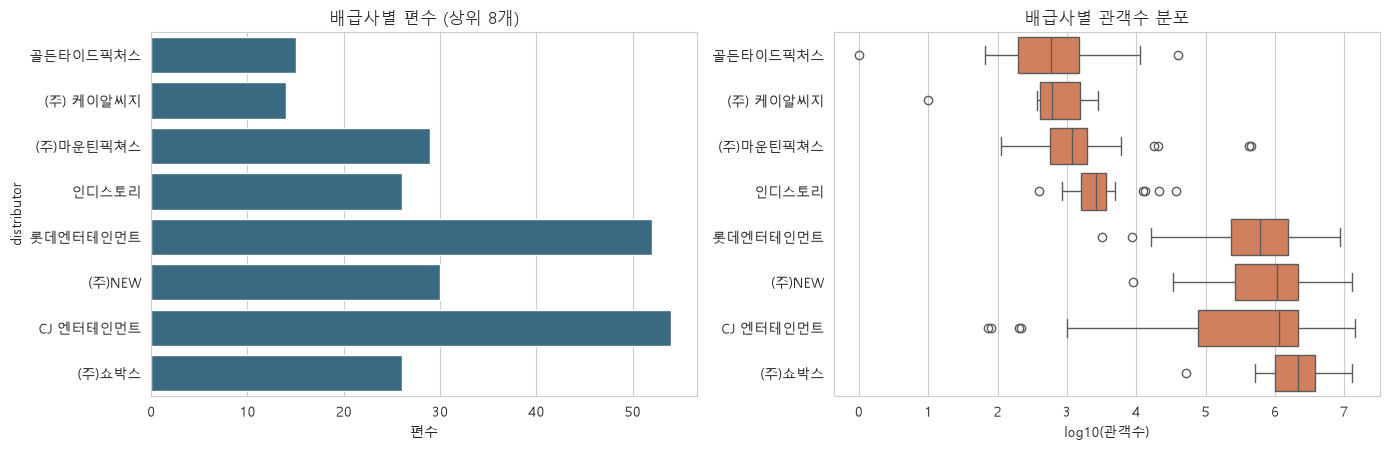

In [10]:
순서 = 요약.sort_values('관객중앙').index

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

sns.countplot(y='distributor', data=d8, order=순서, ax=ax[0], color='#2E6E8E')
ax[0].set_title('배급사별 편수 (상위 8개)')
ax[0].set_xlabel('편수')

sns.boxplot(y='distributor', x='log관객수', data=d8, order=순서,
            ax=ax[1], color='#E4794A')
ax[1].set_title('배급사별 관객수 분포')
ax[1].set_xlabel('log10(관객수)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

메이저 4사(쇼박스·CJ·NEW·롯데)와 독립영화 배급사(인디스토리·마운틴픽쳐스 등)가 완전히 갈린다.
메이저는 관객 중앙값이 60만~210만인 반면, 독립계열은 600~2,600명 수준이다.
스태프 중앙값도 300명 대 30명으로 함께 차이가 나므로, **배급사 효과와 제작 규모 효과가 섞여 있다.**

## 5-3. `genre` — 장르

In [11]:
장르요약 = df.groupby('genre').agg(
    편수=('title', 'size'),
    관객중앙=('box_off_num', 'median'),
    관객평균=('box_off_num', 'mean'),
).sort_values('관객중앙', ascending=False).round(0)
장르요약

,편수,관객중앙,관객평균
genre,,,
느와르,27,1646142.0,2263695.0
액션,28,1147846.0,2203974.0
코미디,53,210775.0,1193914.0
공포,42,179810.0,590833.0
서스펜스,2,82611.0,82611.0
애니메이션,21,23802.0,181927.0
SF,13,9323.0,1788346.0
드라마,221,7173.0,625690.0
뮤지컬,5,4778.0,6627.0


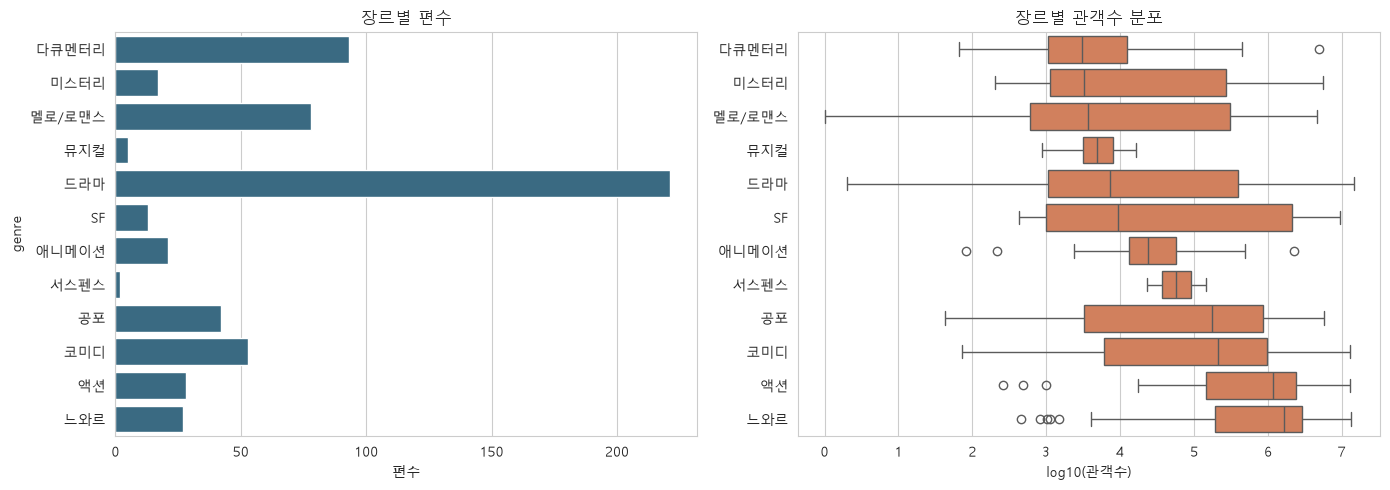

In [12]:
순서 = 장르요약.sort_values('관객중앙').index

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(y='genre', data=df, order=순서, ax=ax[0], color='#2E6E8E')
ax[0].set_title('장르별 편수')
ax[0].set_xlabel('편수')

sns.boxplot(y='genre', x='log관객수', data=df, order=순서,
            ax=ax[1], color='#E4794A')
ax[1].set_title('장르별 관객수 분포')
ax[1].set_xlabel('log10(관객수)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

**중앙값과 평균의 순위가 다르다.** SF는 중앙값이 9,323명인데 평균은 179만 명이다.
`설국열차`, `해적` 같은 소수의 대흥행작이 평균을 끌어올린 것으로,
**평균만 보면 SF가 액션보다 흥행하는 것처럼 잘못 읽게 된다.**

또한 서스펜스 2편, 뮤지컬 5편, SF 13편은 표본이 적어 결론을 내기 어렵다.

## 5-4. `release_time` — 개봉일

In [13]:
print('[연도별]')
print(df.groupby('연도').agg(편수=('title', 'size'),
                           관객중앙=('box_off_num', 'median'),
                           스태프중앙=('num_staff', 'median')).round(0))
print()
print('[요일별] 0=월요일')
print(df['release_time'].dt.dayofweek.value_counts().sort_index())

[연도별]
       편수     관객중앙  스태프중앙
연도                       
2010   90  28376.0  150.0
2011   80  18904.0   64.0
2012   88  20688.0   70.0
2013   95  14188.0   59.0
2014  127   7721.0   96.0
2015  120   7988.0   73.0

[요일별] 0=월요일
release_time
0      4
1      2
2    107
3    484
4      2
5      1
Name: count, dtype: int64


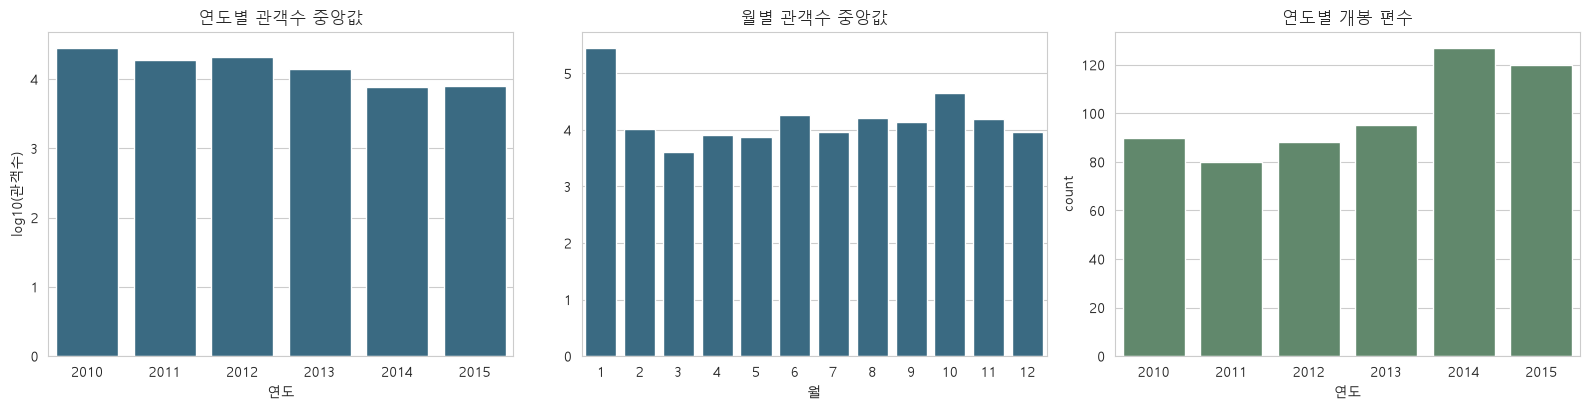

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

sns.barplot(x='연도', y='log관객수', data=df, estimator=np.median,
            errorbar=None, ax=ax[0], color='#2E6E8E')
ax[0].set_title('연도별 관객수 중앙값')
ax[0].set_ylabel('log10(관객수)')

sns.barplot(x='월', y='log관객수', data=df, estimator=np.median,
            errorbar=None, ax=ax[1], color='#2E6E8E')
ax[1].set_title('월별 관객수 중앙값')
ax[1].set_ylabel('')

sns.countplot(x='연도', data=df, ax=ax[2], color='#5A8F69')
ax[2].set_title('연도별 개봉 편수')

plt.tight_layout()
plt.show()

- **개봉 편수는 90편 → 120편으로 늘었는데 관객 중앙값은 28,376명 → 7,988명으로 줄었다.**
  작은 영화가 많이 개봉했기 때문으로 보인다.
- 월별로는 **1월이 가장 높다**(설 연휴), 3월이 가장 낮다.
- 요일은 **목요일 개봉이 484편(81%)** 으로 한국 영화 개봉 관행을 보여준다. 분석 가치는 낮다.

## 5-5. `time` — 상영시간

In [15]:
df['시간구간'] = pd.cut(df['time'], [0, 80, 95, 110, 125, 200],
                    labels=['~80분', '81-95', '96-110', '111-125', '126분~'])
print(df.groupby('시간구간', observed=True).agg(
    편수=('title', 'size'), 관객중앙=('box_off_num', 'median')).round(0))
print()
print('상영시간과 log관객수의 상관 :',
      round(df[['time', 'log관객수']].corr().iloc[0, 1], 3))

          편수       관객중앙
시간구간                   
~80분      79     1068.0
81-95    163     2703.0
96-110   174    14037.0
111-125  137   714136.0
126분~     47  1762733.0

상영시간과 log관객수의 상관 : 0.597


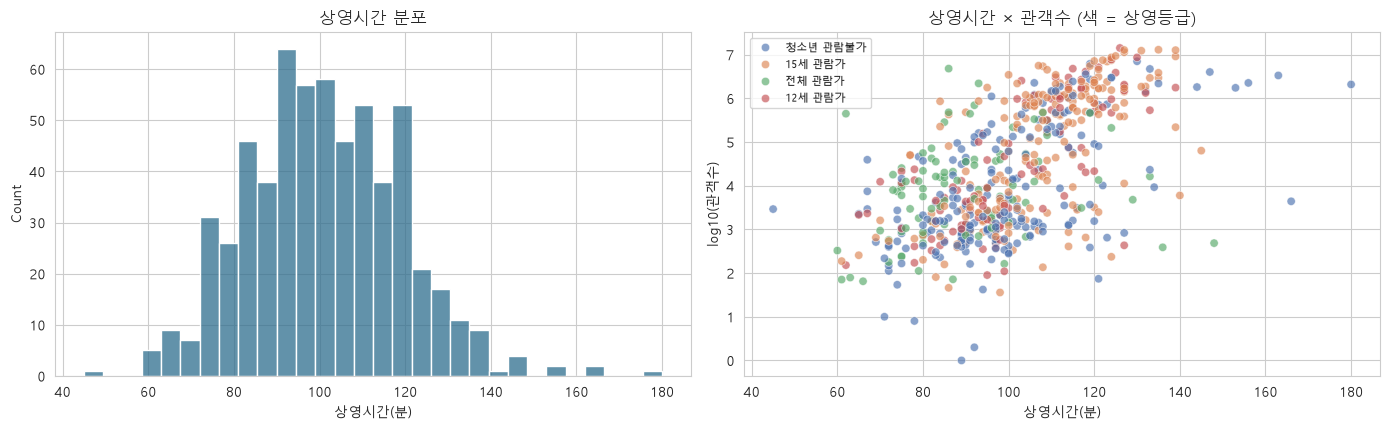

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

sns.histplot(x='time', data=df, bins=30, ax=ax[0], color='#2E6E8E')
ax[0].set_title('상영시간 분포')
ax[0].set_xlabel('상영시간(분)')

sns.scatterplot(x='time', y='log관객수', data=df, hue='screening_rat',
                alpha=0.65, ax=ax[1])
ax[1].set_title('상영시간 × 관객수 (색 = 상영등급)')
ax[1].set_xlabel('상영시간(분)')
ax[1].set_ylabel('log10(관객수)')
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

구간이 올라갈수록 관객수가 **단조 증가**한다(상관 0.441).
다만 이는 "길게 만들면 흥행한다"기보다, **상업영화일수록 러닝타임이 길다**는 관계로 읽는 것이 타당하다.

## 5-6. `screening_rat` — 상영등급

In [17]:
등급요약 = df.groupby('screening_rat').agg(
    편수=('title', 'size'),
    관객중앙=('box_off_num', 'median'),
    스태프중앙=('num_staff', 'median'),
).sort_values('관객중앙', ascending=False).round(0)
등급요약

,편수,관객중앙,스태프중앙
screening_rat,,,
15세 관람가,202,242381.0,202.0
12세 관람가,102,19323.0,72.0
전체 관람가,92,8325.0,9.0
청소년 관람불가,204,3008.0,78.0


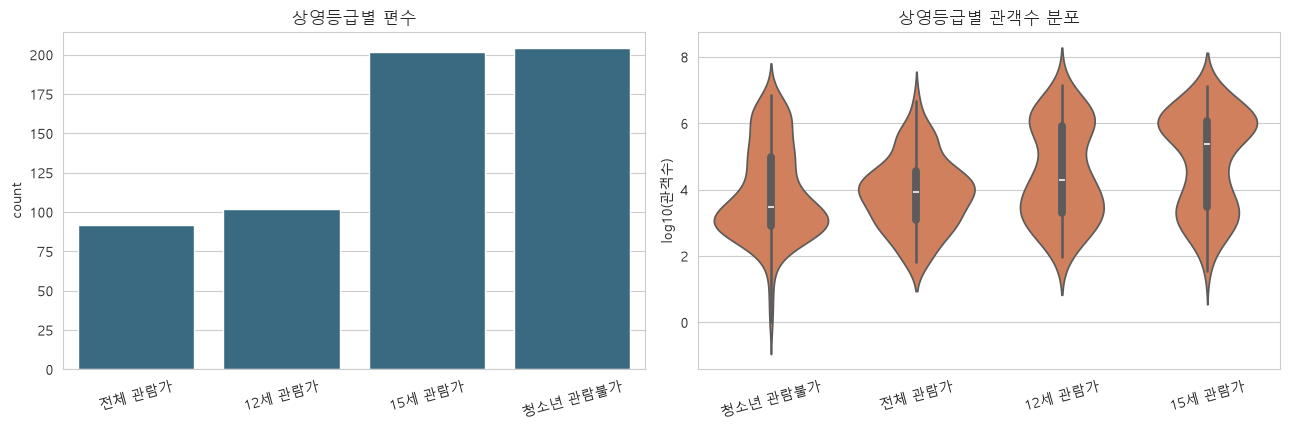

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

sns.countplot(x='screening_rat', data=df, ax=ax[0], color='#2E6E8E',
              order=등급요약.sort_values('편수').index)
ax[0].set_title('상영등급별 편수')
ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=15)

sns.violinplot(x='screening_rat', y='log관객수', data=df, ax=ax[1],
               order=등급요약.sort_values('관객중앙').index, color='#E4794A')
ax[1].set_title('상영등급별 관객수 분포')
ax[1].set_xlabel('')
ax[1].set_ylabel('log10(관객수)')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

등급 간 차이는 장르만큼 크지 않다. 청소년 관람불가가 204편으로 가장 많은데,
이는 독립·예술영화가 이 등급을 많이 받기 때문으로 보인다.

## 5-7. `director` — 감독

472명 중 2편 이상은 99명뿐이라 개별 감독 비교는 표본이 부족하다.
대신 **데이터 내 출연 편수**로 바꿔서 본다.

       편수     관객중앙
감독편수              
1     373   7908.0
2     158  41762.0
3      42   3228.0
4      20   2976.0
7       7  46212.0


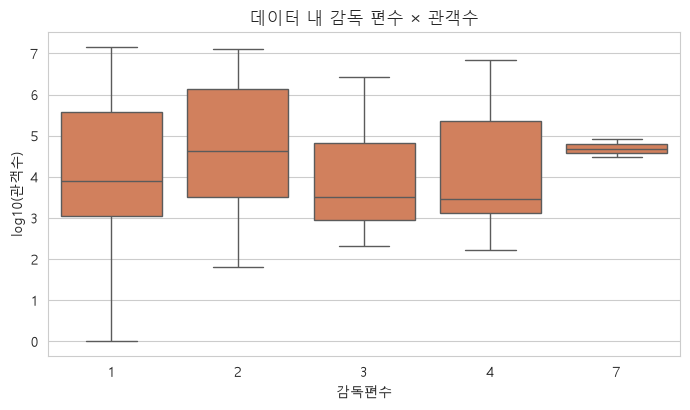

In [19]:
df['감독편수'] = df['director'].map(df['director'].value_counts())
print(df.groupby('감독편수').agg(편수=('title', 'size'),
                             관객중앙=('box_off_num', 'median')).round(0))

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.boxplot(x='감독편수', y='log관객수', data=df, ax=ax, color='#E4794A')
ax.set_title('데이터 내 감독 편수 × 관객수')
ax.set_ylabel('log10(관객수)')
plt.tight_layout()
plt.show()

**다작 감독일수록 오히려 관객이 적다.** 홍상수 감독(7편)처럼 저예산 영화를 자주 만드는
감독이 편수 상위에 오르기 때문이다. "많이 만들면 흥행한다"는 관계가 아니다.

## 5-8. `dir_prev_bfnum` — 감독 전작 관객수

전작이 있는 감독(270편)만 대상으로 본다.

전작 관객수 × 이번 관객수 상관 (둘 다 로그) : 0.406


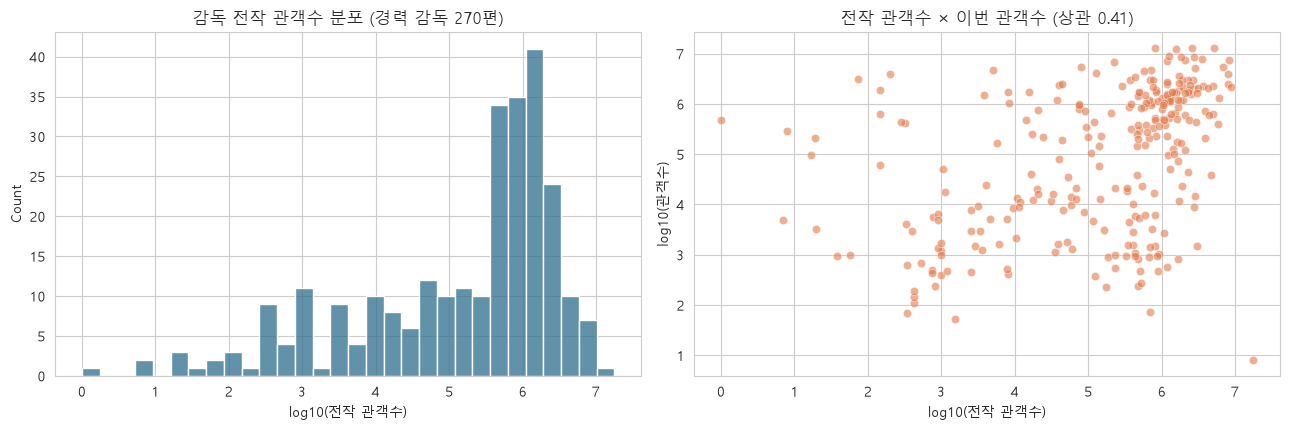

In [20]:
경력 = df[df['dir_prev_num'] > 0].copy()
경력['log전작관객'] = np.log10(경력['dir_prev_bfnum'])
상관 = 경력[['log전작관객', 'log관객수']].corr().iloc[0, 1]
print('전작 관객수 × 이번 관객수 상관 (둘 다 로그) :', round(상관, 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

sns.histplot(x='log전작관객', data=경력, bins=30, ax=ax[0], color='#2E6E8E')
ax[0].set_title('감독 전작 관객수 분포 (경력 감독 270편)')
ax[0].set_xlabel('log10(전작 관객수)')

sns.scatterplot(x='log전작관객', y='log관객수', data=경력,
                alpha=0.6, ax=ax[1], color='#E4794A')
ax[1].set_title(f'전작 관객수 × 이번 관객수 (상관 {상관:.2f})')
ax[1].set_xlabel('log10(전작 관객수)')
ax[1].set_ylabel('log10(관객수)')

plt.tight_layout()
plt.show()

전작이 흥행한 감독의 다음 작품도 흥행하는 경향이 뚜렷하다. 다만 산포가 커서
전작만으로 예측하기는 어렵다.

## 5-9. `dir_prev_num` — 감독 전작 편수

               편수       관객중앙  스태프중앙
dir_prev_num                       
0             330     3402.0   38.0
1             113    38809.0  136.0
2              86   180706.0  152.0
3              47   828029.0  295.0
4              20  1174766.0  342.0
5               4   371255.0  366.0


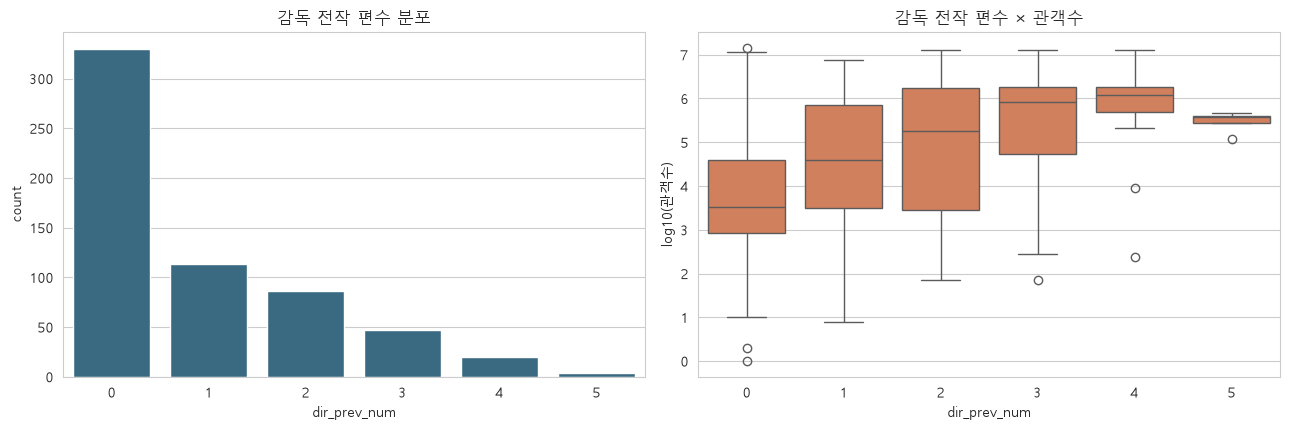

In [21]:
print(df.groupby('dir_prev_num').agg(
    편수=('title', 'size'),
    관객중앙=('box_off_num', 'median'),
    스태프중앙=('num_staff', 'median')).round(0))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

sns.countplot(x='dir_prev_num', data=df, ax=ax[0], color='#2E6E8E')
ax[0].set_title('감독 전작 편수 분포')

sns.boxplot(x='dir_prev_num', y='log관객수', data=df, ax=ax[1], color='#E4794A')
ax[1].set_title('감독 전작 편수 × 관객수')
ax[1].set_ylabel('log10(관객수)')

plt.tight_layout()
plt.show()

In [22]:
# 신인 vs 경력 비교
df.groupby('신인감독').agg(
    편수=('title', 'size'),
    관객중앙=('box_off_num', 'median'),
    스태프중앙=('num_staff', 'median'),
).round(1)

,편수,관객중앙,스태프중앙
신인감독,,,
경력,270,222258.0,215.5
신인,330,3401.5,37.5


신인 감독 3,402명 vs 경력 감독 222,258명으로 **65배 차이**가 난다.

그런데 **스태프 중앙값도 37.5명 vs 215.5명으로 함께 커진다.**
즉 감독 경력과 제작 규모가 같이 움직이고 있어서, 이 차이가 감독 때문인지
예산 때문인지 지금 상태로는 구분할 수 없다. → 뒤에서 규모를 고정하고 다시 확인한다.

## 5-10. `num_staff` — 스태프 수

In [23]:
print('스태프 수와 log관객수의 상관 :',
      round(df[['num_staff', 'log관객수']].corr().iloc[0, 1], 3))
print()
print(df.groupby('규모', observed=True).agg(
    편수=('title', 'size'), 관객중앙=('box_off_num', 'median')).round(0))

스태프 수와 log관객수의 상관 : 0.744

          편수       관객중앙
규모                     
0명        32      996.0
1-20     140     2166.0
21-80    125     1759.0
81-200   112     9180.0
201-400  134   740894.0
401+      57  1717566.0


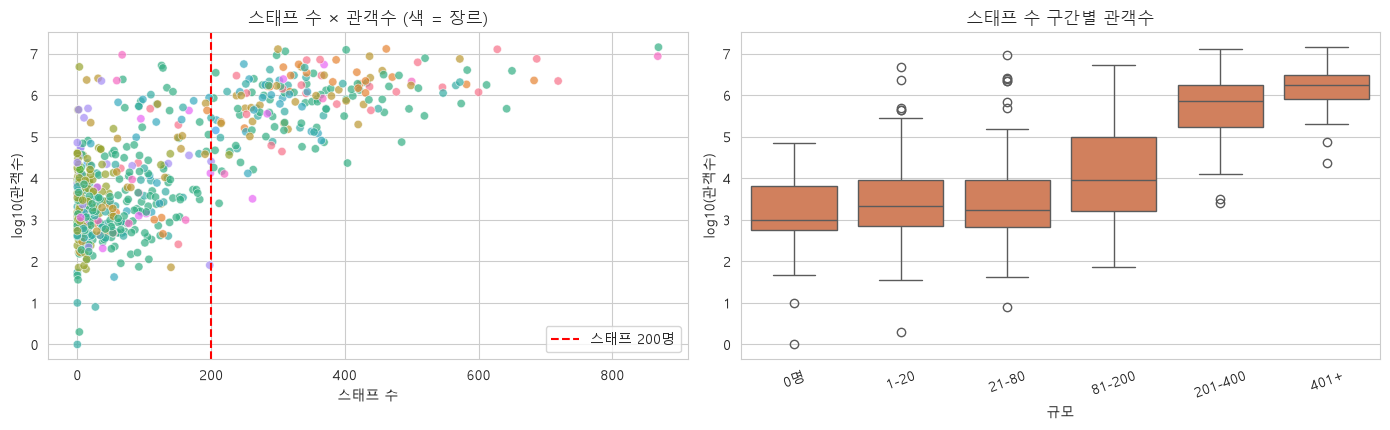

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

sns.scatterplot(x='num_staff', y='log관객수', data=df, hue='genre',
                alpha=0.7, ax=ax[0], legend=False)
ax[0].axvline(200, color='red', linestyle='--', linewidth=1.5, label='스태프 200명')
ax[0].set_title('스태프 수 × 관객수 (색 = 장르)')
ax[0].set_xlabel('스태프 수')
ax[0].set_ylabel('log10(관객수)')
ax[0].legend()

sns.boxplot(x='규모', y='log관객수', data=df, ax=ax[1], color='#E4794A')
ax[1].set_title('스태프 수 구간별 관객수')
ax[1].set_ylabel('log10(관객수)')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**수치형 변수 중 관객수와 가장 강하게 연결된다(상관 0.544).**

주목할 점은 관계가 직선이 아니라 **계단 모양**이라는 것이다.
81~200명 구간의 관객 중앙값이 9,180명인데, 201~400명 구간은 740,894명으로 **약 80배 뛴다.**
산점도에서도 스태프 200명을 경계로 점의 분포가 뚜렷하게 갈린다.

## 5-11. `num_actor` — 주연배우 수

In [25]:
print('주연배우 수와 log관객수의 상관 :',
      round(df[['num_actor', 'log관객수']].corr().iloc[0, 1], 3))
print()
print(df[df['num_actor'] <= 8].groupby('num_actor').agg(
    편수=('title', 'size'), 관객중앙=('box_off_num', 'median')).round(0))

주연배우 수와 log관객수의 상관 : 0.112

            편수      관객중앙
num_actor               
0            9     862.0
1           35    8083.0
2          154    9264.0
3          143   12486.0
4          114    8208.0
5           58   20690.0
6           33   51207.0
7           16   19178.0
8           16  295863.0


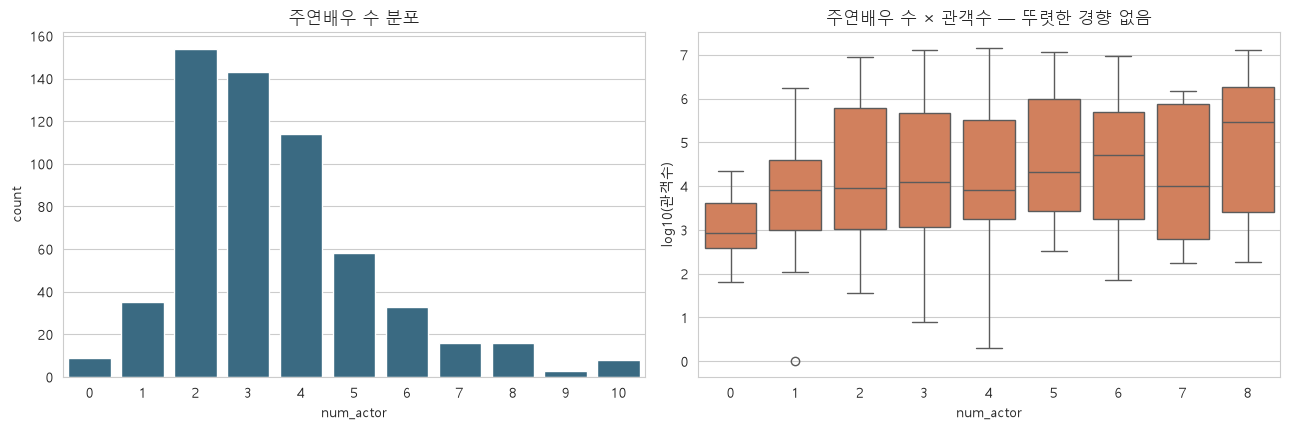

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

sns.countplot(x='num_actor', data=df[df['num_actor'] <= 10],
              ax=ax[0], color='#2E6E8E')
ax[0].set_title('주연배우 수 분포')

sns.boxplot(x='num_actor', y='log관객수', data=df[df['num_actor'] <= 8],
            ax=ax[1], color='#E4794A')
ax[1].set_title('주연배우 수 × 관객수 — 뚜렷한 경향 없음')
ax[1].set_ylabel('log10(관객수)')

plt.tight_layout()
plt.show()

상관이 0.111로 거의 없다. **배우를 많이 쓴다고 관객이 늘지는 않는다.**
"관계가 없다"는 것도 결과이므로 기록해 둔다.

## 5-12. `box_off_num` — 관객수 (목표 변수)

In [27]:
print('왜도(skew)  원본 : %.2f' % df['box_off_num'].skew())
print('           로그 : %.2f' % df['log관객수'].skew())
print()
print(df['box_off_num'].quantile([.1, .25, .5, .75, .9, .99]).round(0))

왜도(skew)  원본 : 4.33
           로그 : 0.12

0.10        429.0
0.25       1297.0
0.50      12591.0
0.75     479887.0
0.90    1987835.0
0.99    9370596.0
Name: box_off_num, dtype: float64


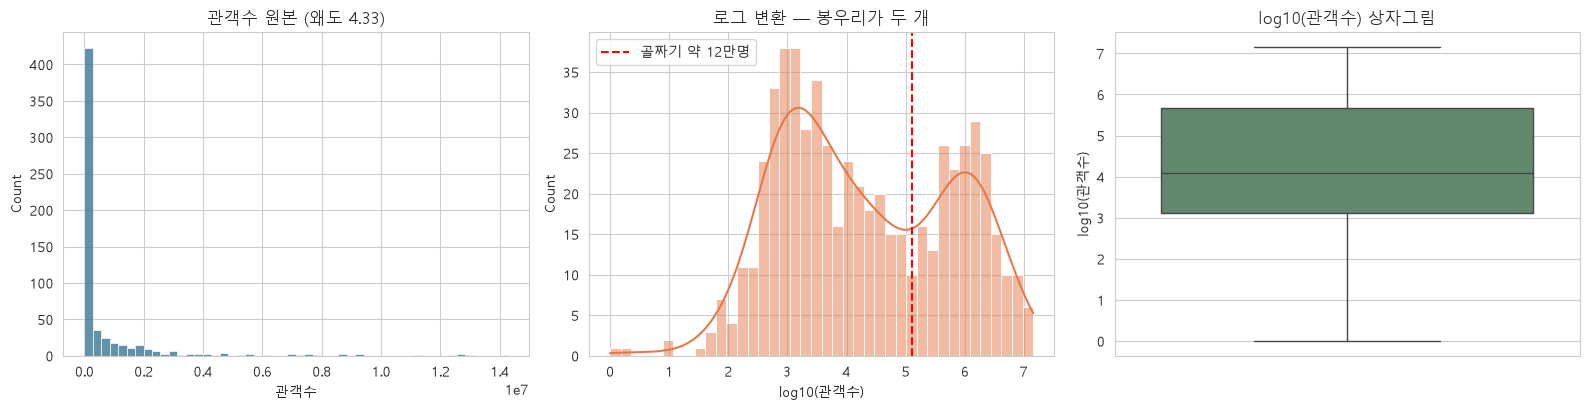

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

sns.histplot(x='box_off_num', data=df, bins=50, ax=ax[0], color='#2E6E8E')
ax[0].set_title('관객수 원본 (왜도 4.33)')
ax[0].set_xlabel('관객수')

sns.histplot(x='log관객수', data=df, bins=40, kde=True, ax=ax[1], color='#E4794A')
ax[1].axvline(5.1, color='red', linestyle='--', linewidth=1.5,
              label='골짜기 약 12만명')
ax[1].set_title('로그 변환 — 봉우리가 두 개')
ax[1].set_xlabel('log10(관객수)')
ax[1].legend()

sns.boxplot(y='log관객수', data=df, ax=ax[2], color='#5A8F69')
ax[2].set_title('log10(관객수) 상자그림')
ax[2].set_ylabel('log10(관객수)')

plt.tight_layout()
plt.show()

로그 변환으로 왜도가 4.33 → 0.12로 크게 줄어 정규분포에 가까워진다.

그런데 변환 후 히스토그램을 보면 **봉우리가 하나가 아니라 두 개다.**
약 1,000명대와 100만 명대에 각각 몰려 있고, 그 사이(약 12만 명)가 비어 있다.
독립·예술영화와 상업영화라는 성격이 다른 두 집단이 한 데이터에 섞여 있음을 시사한다.

---
## 6. 수치형 변수 상관관계 종합

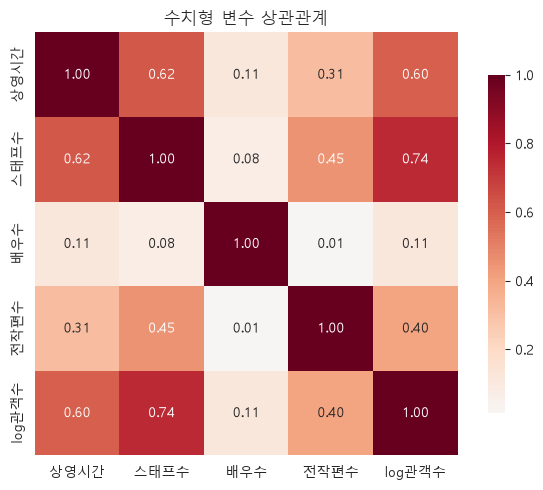

In [29]:
수치형 = df[['time', 'num_staff', 'num_actor', 'dir_prev_num', 'log관객수']].copy()
수치형.columns = ['상영시간', '스태프수', '배우수', '전작편수', 'log관객수']

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(수치형.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('수치형 변수 상관관계')
plt.tight_layout()
plt.show()

---
## 7. 교란 확인 — 제작 규모를 고정하면?

5-9에서 신인 감독과 경력 감독의 관객수가 65배 차이 났지만,
스태프 수도 함께 달랐다. 제작 규모를 **같은 수준으로 맞추고** 다시 비교한다.

In [30]:
df['규모3'] = pd.cut(df['num_staff'], [-1, 80, 250, 900],
                   labels=['소(~80)', '중(81~250)', '대(251+)'])

비교 = df.pivot_table(index='신인감독', columns='규모3',
                     values='box_off_num', aggfunc='median', observed=True)
편수 = df.pivot_table(index='신인감독', columns='규모3',
                    values='title', aggfunc='size', observed=True)
print('[관객수 중앙값]'); print(비교.round(0))
print()
print('[편수]'); print(편수)

[관객수 중앙값]
규모3   소(~80)  중(81~250)    대(251+)
신인감독                              
경력    1878.0    35567.0  1310895.0
신인    1806.0     9323.0   885336.0

[편수]
규모3   소(~80)  중(81~250)  대(251+)
신인감독                            
경력        78         67      125
신인       219         71       40


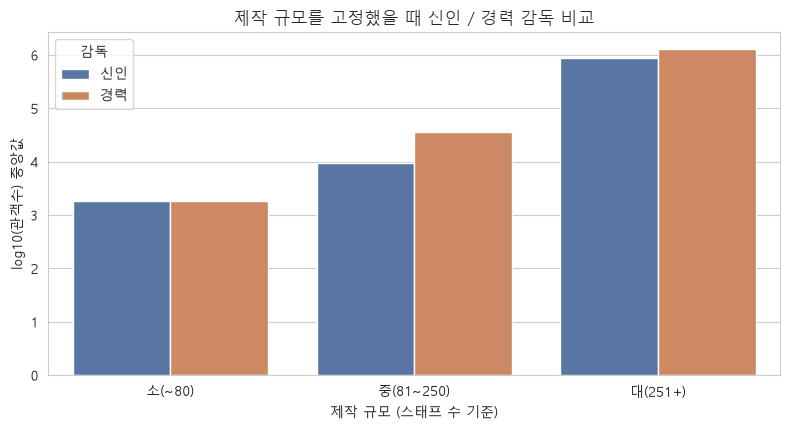

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.4))
sns.barplot(x='규모3', y='log관객수', hue='신인감독', data=df,
            estimator=np.median, errorbar=None, ax=ax)
ax.set_title('제작 규모를 고정했을 때 신인 / 경력 감독 비교')
ax.set_xlabel('제작 규모 (스태프 수 기준)')
ax.set_ylabel('log10(관객수) 중앙값')
ax.legend(title='감독')
plt.tight_layout()
plt.show()

**65배였던 차이가 규모를 고정하니 1~4배로 줄어든다.**
특히 소규모(스태프 80명 이하)에서는 신인 1,806명 / 경력 1,878명으로 거의 같다.

신인 감독이 흥행을 못 하는 것이 아니라, **신인에게는 큰 규모의 영화가 맡겨지지 않는다**는
해석이 타당하다. 제작 규모가 감독 경력과 관객수 사이의 **교란 변수**였던 것이다.

---
## 8. EDA 정리

### 변수별 신호 유무

| 변수 | 관객수와의 관계 | 비고 |
|---|---|---|
| `title` | 없음 | 식별자 |
| `distributor` | **강함** | 메이저 / 독립계열이 갈림, 규모와 섞임 |
| `genre` | **강함** | 중앙값과 평균 순위가 다름 |
| `release_time` | 보통 | 연도별 하락 추세, 1월이 높음 |
| `time` | 보통 (0.441) | 상업영화일수록 길다는 관계 |
| `screening_rat` | 약함 | 장르만큼 크지 않음 |
| `director` | 약함 | 다작 감독일수록 오히려 적음 |
| `dir_prev_bfnum` | 보통 | 전작 흥행이 이어지는 경향 |
| `dir_prev_num` | **강함** | 단 규모와 교란됨 |
| `num_staff` | **가장 강함 (0.544)** | 200명 경계로 계단형 |
| `num_actor` | **없음 (0.111)** | 배우 수는 흥행과 무관 |

### 확인한 것

1. **`dir_prev_bfnum`의 결측 55%는 결측이 아니라 "데뷔작"이라는 정보다.** 0으로 채우는 것이 맞다.
2. **관객수는 로그 변환이 필수다.** 왜도 4.33 → 0.12. 변환 후 봉우리가 두 개로 나뉜다.
3. **제작 규모(스태프 수)가 가장 강한 변수이고, 관계는 직선이 아니라 200명 부근의 계단형이다.**
4. **감독 경력의 효과는 대부분 제작 규모로 설명된다.** 규모를 고정하면 65배 차이가 1~4배로 줄어든다.
5. **주연배우 수는 관객수와 관계가 없다.**

### 다음 단계

- 제작 규모를 고정한 상태에서 장르·상영등급·개봉시기의 효과가 남는지 확인
- 배급사 효과가 규모와 분리되는지 확인
- 위 결과를 바탕으로 시각화 10개 이상 구성